In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("full_dataset.csv", parse_dates=['application_date'])
print(df.shape)
print(df.head())

(28623, 7)
   est_const_cost  dwelling_units_created  is_approved  structure_type_id  \
0             NaN                       0            0                166   
1             NaN                       0            1                  9   
2          1000.0                       0            1                202   
3          2000.0                       0            1                109   
4         50000.0                       0            0                164   

   work_type_id  ward_code application_date  
0            20      104.0       2019-09-18  
1            21      120.0       2019-05-11  
2           131      188.0       1993-11-08  
3            14      250.0       2010-07-27  
4            73      225.0       2009-09-11  


In [3]:
# Select columns type int64
int_cols = df.select_dtypes(include='int64').columns

# Convert to float64
df[int_cols] = df[int_cols].astype(float)

# Verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28623 entries, 0 to 28622
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   est_const_cost          14881 non-null  float64       
 1   dwelling_units_created  28623 non-null  float64       
 2   is_approved             28623 non-null  float64       
 3   structure_type_id       28623 non-null  float64       
 4   work_type_id            28623 non-null  float64       
 5   ward_code               27749 non-null  float64       
 6   application_date        28623 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.5 MB


In [4]:
df.isnull().sum()

est_const_cost            13742
dwelling_units_created        0
is_approved                   0
structure_type_id             0
work_type_id                  0
ward_code                   874
application_date              0
dtype: int64

## DATA CLEANING

In [5]:
# Rows before cleaning
rows_before = len(df)
print("Rows before cleaning:", rows_before)

# Fix mistakes in dwelling_units_created
df['dwelling_units_created'] = df['dwelling_units_created'].clip(lower=0)

# Remove null cost where cost is the dependent variable
df_cost = df.dropna(subset=['est_const_cost']).copy()
df_apd = df.copy()
df_units = df.copy()

# Fill missing ward_codes with -1 (unknown)
for d in [df_cost, df_apd, df_units]:
    d['ward_code'] = d['ward_code'].fillna(-1)

# Rows after cleaning (using df_cost as the cleaned set for cost analysis)
rows_after = len(df_cost)
print("Rows after cleaning:", rows_after)

Rows before cleaning: 28623
Rows after cleaning: 14881


## Assumption Checks for Regression (Q-Q plots, residuals)

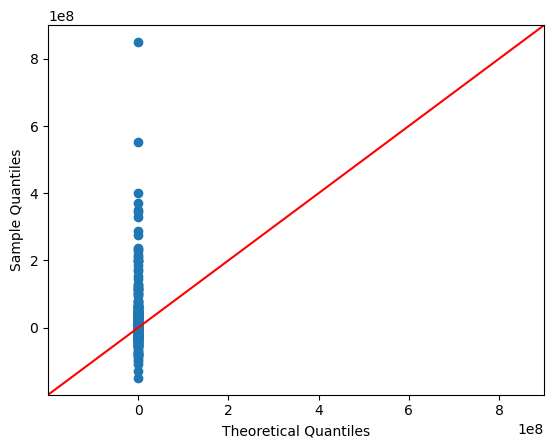

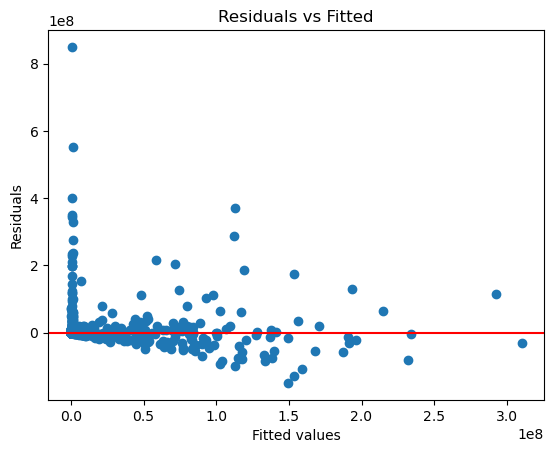

                 Variable       VIF
0       structure_type_id  4.985757
1            work_type_id  5.039075
2               ward_code  3.787032
3  dwelling_units_created  1.016813


In [6]:
import statsmodels.api as sm
from scipy import stats

X = df_cost[['structure_type_id','work_type_id','ward_code','dwelling_units_created']]
y = df_cost['est_const_cost']

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# Q-Q plot
sm.qqplot(model.resid, line='45')
plt.show()

# Residuals vs fitted
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

## RQ1: Costs vs Structure Type

=== ORIGINAL DISTRIBUTION ===
Min: 0.0
Max: 850971654.0
Mean: 1745930.0008702374
Skewness: 21.648149943957872
Kurtosis: 677.5543521020786




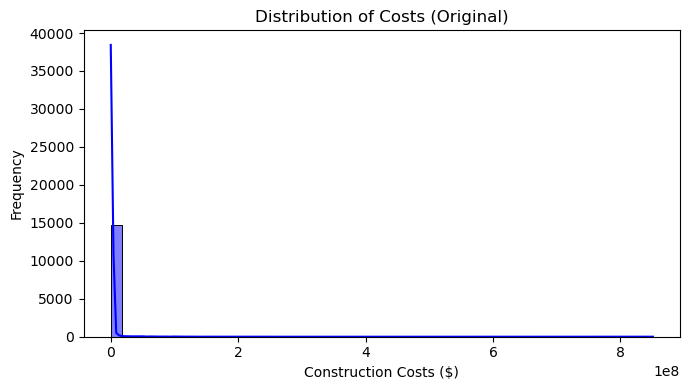

=== LOG TRANSFORMATION ===
Skewness: 0.33682979518393696
Kurtosis: 0.9569811453263437




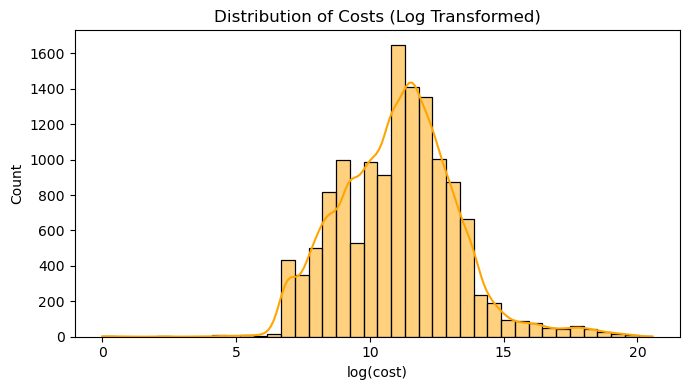

=== SQRT TRANSFORMATION ===
Skewness: 9.139923157791234
Kurtosis: 111.29917382965243




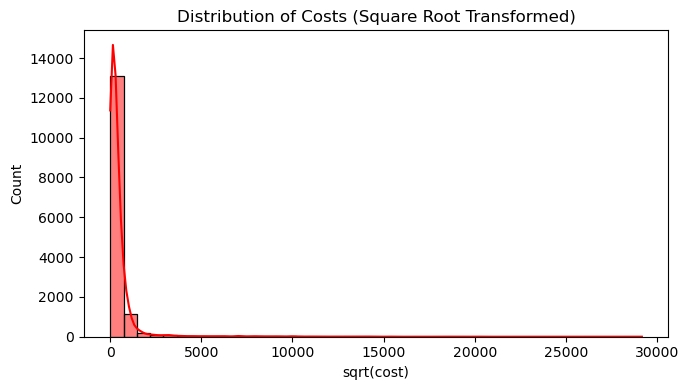

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

col = 'est_const_cost'
data = df_cost[col]

print("=== ORIGINAL DISTRIBUTION ===")
print("Min:", data.min())
print("Max:", data.max())
print("Mean:", data.mean())
print("Skewness:", data.skew())
print("Kurtosis:", data.kurtosis())
print("\n")

# -------------------------------------------------------
# 1. Original Histogram
# -------------------------------------------------------
plt.figure(figsize=(7,4))
sns.histplot(data, kde=True, bins=50, color='blue', edgecolor='black')
plt.title("Distribution of Costs (Original)")
plt.xlabel("Construction Costs ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 2. Transformations (log y sqrt)
# -------------------------------------------------------

data_log = np.log(data[data > 0])
data_sqrt = np.sqrt(data)

print("=== LOG TRANSFORMATION ===")
print("Skewness:", data_log.skew())
print("Kurtosis:", data_log.kurtosis())
print("\n")

plt.figure(figsize=(7,4))
sns.histplot(data_log, kde=True, bins=40, color='orange', edgecolor='black')
plt.title("Distribution of Costs (Log Transformed)")
plt.xlabel("log(cost)")
plt.tight_layout()
plt.show()


print("=== SQRT TRANSFORMATION ===")
print("Skewness:", data_sqrt.skew())
print("Kurtosis:", data_sqrt.kurtosis())
print("\n")

plt.figure(figsize=(7,4))
sns.histplot(data_sqrt, kde=True, bins=40, color='red', edgecolor='black')
plt.title("Distribution of Costs (Square Root Transformed)")
plt.xlabel("sqrt(cost)")
plt.tight_layout()
plt.show()

## Test: Kruskal-Wallis

In [8]:
# Grouping cost by structure type
groups_log = [np.log(df_cost[df_cost['structure_type_id']==i]['est_const_cost']) 
              for i in df_cost['structure_type_id'].unique() if (df_cost[df_cost['structure_type_id']==i]['est_const_cost'] > 0).all()]

stat_log, p_log = stats.kruskal(*groups_log)

print("H1 - Kruskal-Wallis Test (Log Transformed)")
print("H statistic:", stat_log)
print("p-value:", p_log)

if p_log < 0.05:
    print("Reject H0: Estimated construction cost differs significantly across structure types.")
else:
    print("Fail to reject H0: No significant difference in estimated construction cost across structure types.")

H1 - Kruskal-Wallis Test (Log Transformed)
H statistic: 117.88734505003679
p-value: 1.3167859988426057e-07
Reject H0: Estimated construction cost differs significantly across structure types.


In [9]:
# RQ1 – Predicting Estimated Construction Cost

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target
X = df_cost[['structure_type_id', 'work_type_id', 'ward_code', 'dwelling_units_created']]
y = np.log1p(df_cost['est_const_cost'])

# Train–test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Linear Regression model
model_cost = LinearRegression()
model_cost.fit(X_train, y_train)

# Predict on test data
y_pred = model_cost.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model for Estimated Construction Cost (Log1p Transformed)")
print("RMSE:", rmse)
print("R² Score:", r2)

# Show first 5 actual vs predicted values
comparison = pd.DataFrame({
    'Actual (log1p)': y_test[:5],
    'Predicted (log1p)': y_pred[:5]})

print("\nActual vs Predicted (first 5 rows):")
print(comparison)

Linear Regression Model for Estimated Construction Cost (Log1p Transformed)
RMSE: 3.816875726935037
R² Score: 0.04656611923730447

Actual vs Predicted (first 5 rows):
       Actual (log1p)  Predicted (log1p)
2340        17.034386          12.444059
25320       10.596660           9.895517
20088        9.210440          10.261191
16659       11.608245          10.107657
6522        10.126671           9.973508


In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Prepare data
X = df_cost[['structure_type_id', 'work_type_id', 'ward_code', 'dwelling_units_created']]
y = np.log1p(df_cost['est_const_cost'])

# Add intercept manually (required for statsmodels)
X_sm = sm.add_constant(X)

# Fit OLS regression model
model_sm = sm.OLS(y, X_sm).fit()

# Extract summary table
summary_table = model_sm.summary2().tables[1]

print(summary_table)


                           Coef.  Std.Err.          t          P>|t|  \
const                   9.218414  0.118297  77.926342   0.000000e+00   
structure_type_id      -0.002399  0.000603  -3.980274   6.916257e-05   
work_type_id            0.014993  0.001193  12.561978   5.204522e-36   
ward_code               0.000044  0.000295   0.147666   8.826086e-01   
dwelling_units_created  0.018916  0.000832  22.731552  1.784705e-112   

                          [0.025    0.975]  
const                   8.986538  9.450290  
structure_type_id      -0.003580 -0.001217  
work_type_id            0.012653  0.017332  
ward_code              -0.000535  0.000623  
dwelling_units_created  0.017285  0.020548  


## RQ2: Predicting Approvals

## Chi-square test

In [11]:
import scipy.stats as stats
import pandas as pd

# Create contingency table: approval by ward
contingency = pd.crosstab(df_apd['ward_code'], df_apd['is_approved'])

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("H2 - Chi-square Test")
print("Chi2 statistic:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Reject H0: Permit approval probability differs across wards.")
else:
    print("Fail to reject H0: No significant difference in permit approval across wards.")

H2 - Chi-square Test
Chi2 statistic: 1855.631332746498
p-value: 3.1143912307214473e-214
Reject H0: Permit approval probability differs across wards.


In [12]:
# Logistic Regression for Hypothesis 2

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

# Define features and Target
X = df_apd[['ward_code', 'structure_type_id', 'work_type_id']]
y = df_apd['is_approved'].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Balanced class weights (data is imbalanced)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.array([0,1]), y=y)
class_weights = {0: weights[0], 1: weights[1]}

# Train Logistic Regression
model_apd = LogisticRegression(max_iter=1000, class_weight=class_weights)
model_apd.fit(X_train, y_train)

# Predict
y_pred = model_apd.predict(X_test)
y_prob = model_apd.predict_proba(X_test)[:,1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Logistic Regression Model (No One-Hot Encoding)")
print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Coefficient importance
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_apd.coef_[0]}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(coef_df)

Logistic Regression Model (No One-Hot Encoding)
Accuracy: 0.5499010131594271
ROC-AUC: 0.5407642946573114
Confusion Matrix:
 [[3569 2229]
 [1636 1153]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.62      0.65      5798
           1       0.34      0.41      0.37      2789

    accuracy                           0.55      8587
   macro avg       0.51      0.51      0.51      8587
weighted avg       0.57      0.55      0.56      8587


Feature Coefficients:
             Feature  Coefficient
2       work_type_id     0.001937
0          ward_code     0.000202
1  structure_type_id    -0.003245


In [13]:
import statsmodels.api as sm

# Prepare data
X = df_apd[['ward_code', 'structure_type_id', 'work_type_id']]
y = df_apd['is_approved'].astype(int)

# Add constant for intercept
X_sm = sm.add_constant(X)

# Fit logistic regression using statsmodels
logit_model = sm.Logit(y, X_sm).fit()

# Extract the full coefficient table
logit_summary = logit_model.summary2().tables[1]

print(logit_summary)

Optimization terminated successfully.
         Current function value: 0.624558
         Iterations 5
                      Coef.  Std.Err.          z         P>|z|    [0.025  \
const             -0.504225  0.044720 -11.275206  1.739706e-29 -0.591874   
ward_code          0.000121  0.000120   1.011503  3.117759e-01 -0.000113   
structure_type_id -0.003006  0.000247 -12.151770  5.613684e-34 -0.003491   
work_type_id       0.001724  0.000405   4.256161  2.079674e-05  0.000930   

                     0.975]  
const             -0.416576  
ward_code          0.000355  
structure_type_id -0.002522  
work_type_id       0.002519  


## RQ3: Predicting Dwelling Units Created

=== ORIGINAL DISTRIBUTION ===
Min: 0.0
Max: 1147.0
Mean: 1.8561995597945709
Median: 0.0
Skewness: 20.851931248188677
Kurtosis: 540.6003911306215




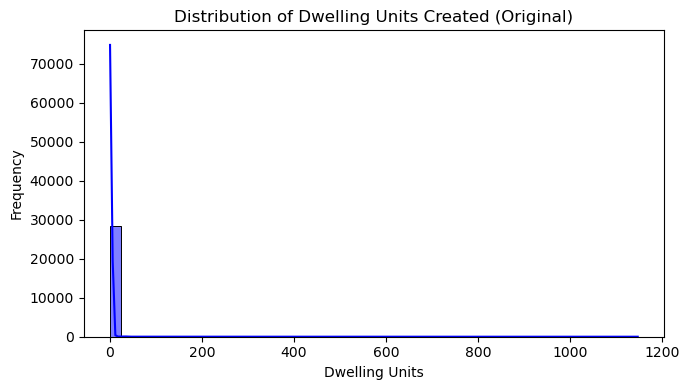

=== LOG1P TRANSFORMATION ===
Skewness: 9.539906189550459
Kurtosis: 101.38639593295228




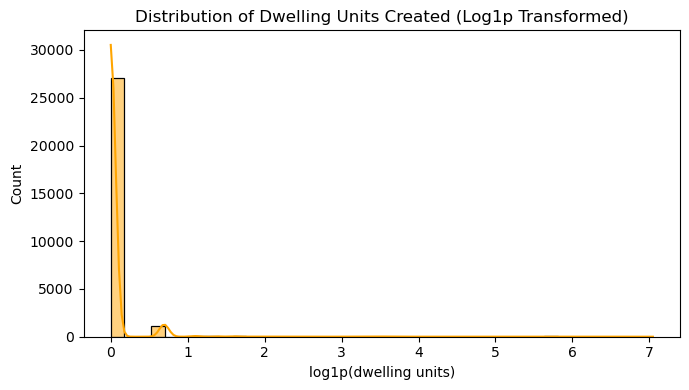

=== SQRT TRANSFORMATION ===
Skewness: 13.529522476470486
Kurtosis: 208.04214912896052




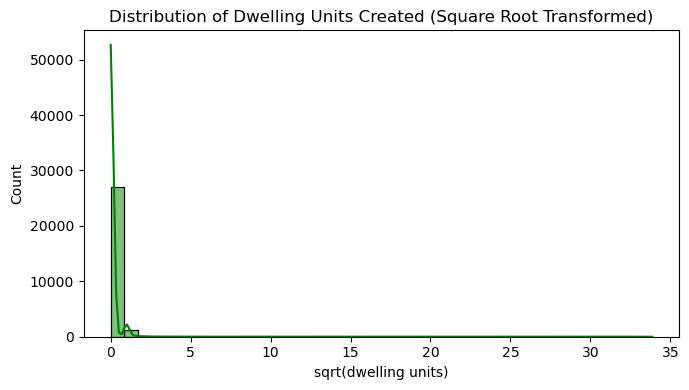

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Análisis descriptivo
col = 'dwelling_units_created'
data = df_units[col]

print("=== ORIGINAL DISTRIBUTION ===")
print("Min:", data.min())
print("Max:", data.max())
print("Mean:", data.mean())
print("Median:", data.median())
print("Skewness:", data.skew())
print("Kurtosis:", data.kurtosis())
print("\n")

# Histograma original
plt.figure(figsize=(7,4))
sns.histplot(data, kde=True, bins=50, color='blue', edgecolor='black')
plt.title("Distribution of Dwelling Units Created (Original)")
plt.xlabel("Dwelling Units")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Transformaciones (log1p y sqrt)
data_log = np.log1p(data)   # log(1 + x) acepta ceros
data_sqrt = np.sqrt(data)

print("=== LOG1P TRANSFORMATION ===")
print("Skewness:", data_log.skew())
print("Kurtosis:", data_log.kurtosis())
print("\n")

plt.figure(figsize=(7,4))
sns.histplot(data_log, kde=True, bins=40, color='orange', edgecolor='black')
plt.title("Distribution of Dwelling Units Created (Log1p Transformed)")
plt.xlabel("log1p(dwelling units)")
plt.tight_layout()
plt.show()

print("=== SQRT TRANSFORMATION ===")
print("Skewness:", data_sqrt.skew())
print("Kurtosis:", data_sqrt.kurtosis())
print("\n")

plt.figure(figsize=(7,4))
sns.histplot(data_sqrt, kde=True, bins=40, color='green', edgecolor='black')
plt.title("Distribution of Dwelling Units Created (Square Root Transformed)")
plt.xlabel("sqrt(dwelling units)")
plt.tight_layout()
plt.show()

## Kruskal-Wallis Test

In [15]:
# Grouping dwelling units by work type
groups_units_log = [np.log1p(df_units[df_units['work_type_id']==i]['dwelling_units_created']) 
                    for i in df_units['work_type_id'].unique()]

stat_units_log, p_units_log = stats.kruskal(*groups_units_log)

print("H3 - Kruskal-Wallis Test (Log Transformed)")
print("H statistic:", stat_units_log)
print("p-value:", p_units_log)

if p_units_log < 0.05:
    print("Reject H0: Work type affects the number of dwelling units created.")
else:
    print("Fail to reject H0: Work type does not significantly affect dwelling units created.")

H3 - Kruskal-Wallis Test (Log Transformed)
H statistic: 17369.83427659168
p-value: 0.0
Reject H0: Work type affects the number of dwelling units created.


In [16]:
# Model 3: Predicting Dwelling Units Created
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Features and target
X = df_units[['structure_type_id', 'work_type_id', 'ward_code']]
y = np.log1p(df_units['dwelling_units_created'])

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the linear regression model
model_units = LinearRegression()
model_units.fit(X_train, y_train)

# Predict on test set
y_pred = model_units.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model for Dwelling Units Created (Log1p Transformed)")
print("RMSE:", rmse)
print("R² Score:", r2)

# Display first 5 actual vs predicted values
print("\nActual vs Predicted (first 5 rows):")
print(pd.DataFrame({'Actual': y_test[:5], 'Predicted': y_pred[:5]}))

Linear Regression Model for Dwelling Units Created (Log1p Transformed)
RMSE: 0.505442941460738
R² Score: 0.024559994588483125

Actual vs Predicted (first 5 rows):
       Actual  Predicted
12741     0.0   0.023398
1660      0.0   0.036060
96        0.0   0.024067
24836     0.0   0.117853
24560     0.0  -0.003125


In [17]:
import statsmodels.api as sm

# Prepare data
X = df_units[['structure_type_id', 'work_type_id', 'ward_code']]
y = np.log1p(df_units['dwelling_units_created'])

# Add constant
X_sm = sm.add_constant(X)

# Fit OLS model
model_units_sm = sm.OLS(y, X_sm).fit()

# Display full coefficient table
coef_table = model_units_sm.summary2().tables[1]
print(coef_table)

                      Coef.  Std.Err.          t          P>|t|    [0.025  \
const              0.012504  0.010142   1.232849   2.176422e-01 -0.007375   
structure_type_id -0.000497  0.000056  -8.836992   1.038409e-18 -0.000608   
work_type_id       0.002245  0.000091  24.750359  7.866219e-134  0.002067   
ward_code          0.000080  0.000027   2.993473   2.760572e-03  0.000028   

                     0.975]  
const              0.032382  
structure_type_id -0.000387  
work_type_id       0.002423  
ward_code          0.000132  
